## Day 3 - Customer Segmentation (K-Means & DBSCAN)

## Prepare RFM for Clustering

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# Load cleaned retail data
df = pd.read_csv('../data/clean_retail.csv')

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create RFM table
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalRevenue', 'sum')
).reset_index()

print(rfm.head())

# Select RFM features
rfm_data = rfm[['Recency', 'Frequency', 'Monetary']]

# Scale
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

print("Scaling done:", rfm_scaled.shape)

   Customer ID  Recency  Frequency  Monetary
0        12346      326         12  77556.46
1        12347        2          8   5633.32
2        12348       75          5   2019.40
3        12349       19          4   4428.69
4        12350      310          1    334.40
Scaling done: (5878, 3)


## Find the Best Number of Clusters (Elbow Method)

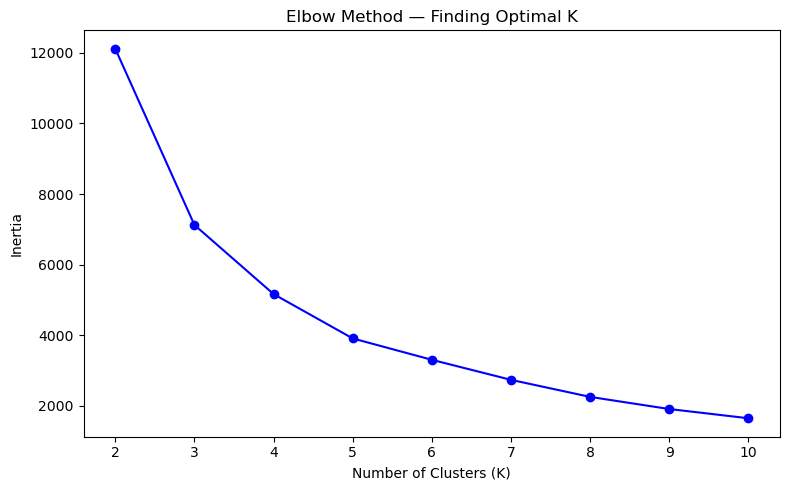

In [13]:
# Try K from 2 to 10, record the inertia (how tight clusters are)
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal K')
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('Day3_elbow.png')
plt.show()
# Look for the "elbow" — where the curve bends. Usually K=4 or 5 for this dataset.

## Silhouette Score

In [14]:
# Silhouette score measures how well-separated clusters are
# Range: -1 to +1. Higher = better
from sklearn.metrics import silhouette_score
silhouette_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.3f}")

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest K = {best_k}")

K=2: Silhouette Score = 0.916
K=3: Silhouette Score = 0.580
K=4: Silhouette Score = 0.591
K=5: Silhouette Score = 0.600
K=6: Silhouette Score = 0.550
K=7: Silhouette Score = 0.549
K=8: Silhouette Score = 0.541
K=9: Silhouette Score = 0.541
K=10: Silhouette Score = 0.501

Best K = 2


## Apply K-Means

In [15]:
# Apply K-Means with best K (let's say K=4)
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = km_final.fit_predict(rfm_scaled)

# Cluster summary
cluster_summary = rfm.groupby('KMeans_Cluster')[['Recency','Frequency','Monetary']].mean()
print(cluster_summary)

                   Recency   Frequency       Monetary
KMeans_Cluster                                       
0               463.032032    2.212212     765.244446
1                67.005728    7.307732    3009.402451
2                25.942857  103.714286   83086.079771
3                 3.500000  212.500000  436835.792500


##  Apply DBSCAN

In [16]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = db.fit_predict(rfm_scaled)

print(f"DBSCAN clusters found: {rfm['DBSCAN_Cluster'].nunique()}")
print(rfm['DBSCAN_Cluster'].value_counts())
# Cluster -1 = noise/outlier customers (very unusual behaviour)

DBSCAN clusters found: 2
DBSCAN_Cluster
 0    5813
-1      65
Name: count, dtype: int64


## Visualize Clusters

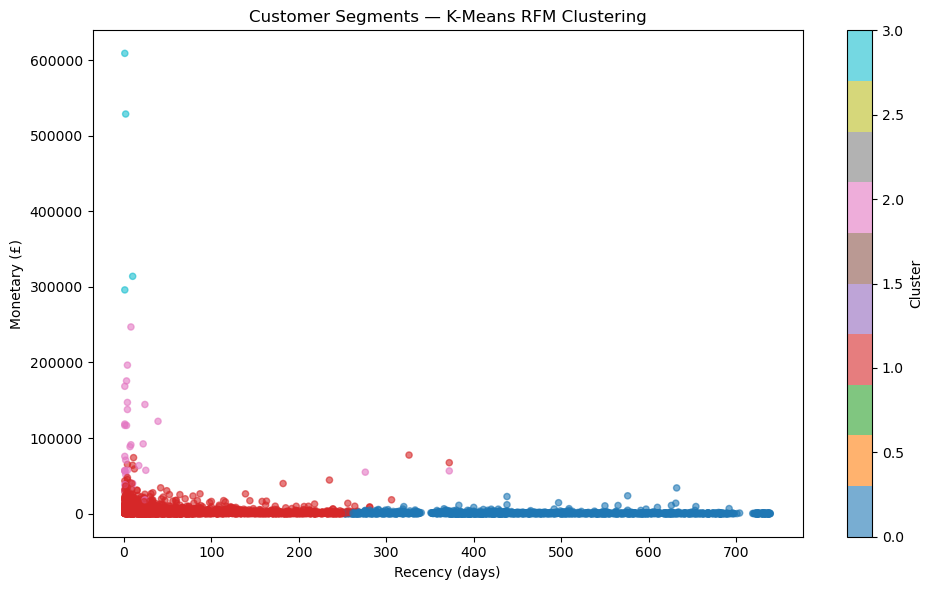

In [17]:
plt.figure(figsize=(10,6))
scatter = plt.scatter(rfm['Recency'], rfm['Monetary'],
                      c=rfm['KMeans_Cluster'], cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Recency (days)')
plt.ylabel('Monetary (£)')
plt.title('Customer Segments — K-Means RFM Clustering')
plt.tight_layout()
plt.savefig('Day3_clusters.png')
plt.show()

In [11]:
rfm.to_csv('../data/rfm_clustered.csv', index=False)

print("Saved: ../data/rfm_clustered.csv")

Saved: ../data/rfm_clustered.csv


In [18]:
rfm = pd.read_csv("../data/rfm_clustered.csv")
print(rfm.columns.tolist())

['Customer ID', 'Recency', 'Frequency', 'Monetary', 'KMeans_Cluster', 'DBSCAN_Cluster']


In [20]:
import pandas as pd

rfm = pd.read_csv("../data/rfm_clustered.csv")

rfm.rename(
    columns={
        "KMeans_Cluster": "KMeans_Label"
    },
    inplace=True
)

rfm.to_csv("../data/rfm_clustered.csv", index=False)

print(rfm.columns.tolist())

['Customer ID', 'Recency', 'Frequency', 'Monetary', 'KMeans_Label', 'DBSCAN_Cluster']
